In [1]:
import time
t1 = time.time()

import scipy.special as sp
import scipy.stats as stats
import math
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam , SGD , Adagrad
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers , initializers
from sklearn.metrics import confusion_matrix
import tensorflow.keras.backend as K
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

gpus = tf.config.experimental.list_physical_devices("GPU")
tf.config.set_visible_devices(gpus[1], "GPU")

### set seed ###
keras.utils.set_random_seed(2330)
tf.config.experimental.enable_op_determinism()

2026-09-21 08:54:01.321458: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
##### load data #####

hhvv_HLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhvv_small_HL.h5"
hhvv_HLdata_file = h5py.File(hhvv_HLdata_path, 'r')
print(hhvv_HLdata_file.keys())

hhvv_LLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhvv_small_LL.h5"
hhvv_LLdata_file = h5py.File(hhvv_LLdata_path, 'r')
print(hhvv_LLdata_file.keys())

hhmumu_HLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhmumu_small_HL.h5"
hhmumu_HLdata_file = h5py.File(hhmumu_HLdata_path, 'r')
print(hhmumu_HLdata_file.keys())

hhmumu_LLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhmumu_small_LL.h5"
hhmumu_LLdata_file = h5py.File(hhmumu_LLdata_path, 'r')
print(hhmumu_LLdata_file.keys())

##### load background data #####

HLdata_path = "/root/data/mucollider/two_boosted/10TeV/test_HLfeature.h5"
HLdata_file = h5py.File(HLdata_path, 'r')
print(HLdata_file.keys())

LLdata_path = "/root/data/mucollider/two_boosted/10TeV/test_LLfeature.h5"
LLdata_file = h5py.File(LLdata_path, 'r')
print(LLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['particle_info']>
<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['particle_info']>
<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_everytype', 'target_sigbg']>
<KeysViewHDF5 ['particle_info']>


In [3]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'M_JJ', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures = ['particle_info']

where_BG = np.where(HLdata_file['target_sigbg'][:]==0)

##### select BTag work point at WP70 (BitNumber 1) #####

hhvv_BTag_leading = ((hhvv_HLdata_file['BTag_leading'][:])&2)
hhvv_BTag_subleading = ((hhvv_HLdata_file['BTag_subleading'][:])&2)

hhmumu_BTag_leading = ((hhmumu_HLdata_file['BTag_leading'][:])&2)
hhmumu_BTag_subleading = ((hhmumu_HLdata_file['BTag_subleading'][:])&2)

BG_BTag_leading = ((HLdata_file['BTag_leading'][:][where_BG])&2)
BG_BTag_subleading = ((HLdata_file['BTag_subleading'][:][where_BG])&2)

##### include other high level features data #####

hhvv_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhvv_HLdata.append(hhvv_BTag_leading)
    elif feature=='BTag_subleading': hhvv_HLdata.append(hhvv_BTag_subleading)
    else: hhvv_HLdata.append(hhvv_HLdata_file[feature][:])
hhvv_HLdata = np.array(hhvv_HLdata).T
print('shape of high level data:', hhvv_HLdata.shape)

hhvv_LLdata = hhvv_LLdata_file['particle_info'][:]
print('shape of low level data:', hhvv_LLdata.shape)

hhmumu_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhmumu_HLdata.append(hhmumu_BTag_leading)
    elif feature=='BTag_subleading': hhmumu_HLdata.append(hhmumu_BTag_subleading)
    else: hhmumu_HLdata.append(hhmumu_HLdata_file[feature][:])
hhmumu_HLdata = np.array(hhmumu_HLdata).T
print('shape of high level data:', hhmumu_HLdata.shape)

hhmumu_LLdata = hhmumu_LLdata_file['particle_info'][:]
print('shape of low level data:', hhmumu_LLdata.shape)

##### include Background data #####

BG_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': BG_HLdata.append(BG_BTag_leading)
    elif feature=='BTag_subleading': BG_HLdata.append(BG_BTag_subleading)
    else: BG_HLdata.append(HLdata_file[feature][:][where_BG])
BG_HLdata = np.array(BG_HLdata).T
print('shape of BG high level data:', BG_HLdata.shape)

BG_LLdata = LLdata_file['particle_info'][:][where_BG]
print('shape of BG low level data:', BG_LLdata.shape)

BG_target = HLdata_file['target_sigbg'][:][where_BG]
print('shape of BG target:', BG_target.shape)

shape of high level data: (251831, 11)
shape of low level data: (251831, 160)
shape of high level data: (267670, 11)
shape of low level data: (267670, 160)
shape of BG high level data: (95526, 11)
shape of BG low level data: (95526, 160)
shape of BG target: (95526,)


In [4]:
##### define the event information #####

BR_hbb = 0.5824
BR_Zqq = 0.69911
Luminosity = 10000   ### unit: fb^-1
sig_simulation_num = 100000
kappa3 = [0.8, 0.84, 0.88, 0.92, 0.96, 1, 1.04, 1.08, 1.12, 1.16, 1.2]

hhvv_Xsection_NoDecay = [3.7154566e-01, 3.617386e-01, 3.524371e-01, 3.4375437e-01, 3.3552887e-01, 3.273126e-01, 3.197475e-01, 3.126318e-01, 3.058909e-01, 2.993453e-01, 2.935034e-01]     ### hhvv unit: fb
hhvv_Xsection = [hhvv_Xsection_NoDecay[i]*BR_hbb*BR_hbb for i in range(11)]
hhvv_event_num = []
for kappa3_val in kappa3:
    hhvv_event_num.append(sum(hhvv_HLdata_file['target_kappa_3'][:]==kappa3_val))

hhmumu_Xsection_NoDecay = [5.5479319e-2, 5.433959e-2, 5.3013911e-2, 5.1688287e-2, 5.06150778e-2, 4.9453757e-2, 4.833858e-2, 4.740145e-2, 4.6342168e-2, 4.543942e-2, 4.4229705e-2]     ### hhmumu unit: fb
hhmumu_Xsection = [hhmumu_Xsection_NoDecay[i]*BR_hbb*BR_hbb for i in range(11)]
hhmumu_event_num = []
for kappa3_val in kappa3:
    hhmumu_event_num.append(sum(hhmumu_HLdata_file['target_kappa_3'][:]==kappa3_val))

bg_processes = ["jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
bg_event_num = [3808, 7352, 3952, 1, 23346, 8, 29532, 27527]
bg_Xsection = [1.08143e-1, 3.539e-2, 1.86879e-2, 2.200885e+1, 7.053723e+1, 1.3355, 3.983523e+1, 7.03508147*BR_hbb*BR_Zqq]     ### unit: fb
bg_simulation_num = 200000

In [5]:
##### load the model #####

# kappa3_str = ["02", "04", "06", "08", "09", "10", "11", "12", "14", "16", "18"]
kappa3_str = ["10_woTDA"]
model_name = ["/root/data/mucollider/two_boosted/10TeV/ML_model/model_mucollider_woTDA.h5"]
model_list = [models.load_model(i) for i in model_name]

2026-09-21 08:54:04.439884: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46696 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6


In [6]:
##### define some useful function

def cal_significance_smallN(s, b):
    if s==0: return 0
    n_obs = s + b
    exact_p_value = sp.gammainc(n_obs, b)
    exact_z_score = stats.norm.isf(exact_p_value)
    if exact_z_score<0: return 0
    else: return exact_z_score
    # return exact_z_score

def cal_significance_diff_hypo(n_obs, b):
    if n_obs > b: exact_p_value = sp.gammainc(n_obs, b)
    elif n_obs < b: exact_p_value = sp.gammaincc(n_obs, b)
    else: return 0
    exact_z_score = stats.norm.isf(exact_p_value)
    # if exact_z_score<0: return 0
    # else: return exact_z_score
    return exact_z_score

def cal_significance(s,b):
    if b==s: return 0
    return np.sqrt(2*((s+b)*np.log(1+s/b)-s))

def cal_mDlnL(n_obs, b):
    return n_obs * np.log(n_obs/b) - n_obs + b

In [7]:
### model test ###

significance_list = []

for model in model_list:
    print("\nmodel: ", kappa3_str[model_list.index(model)])
    
    hhvv_HLtest = []
    hhvv_LLtest = []
    hhvv_prediction = []
    
    hhmumu_HLtest = []
    hhmumu_LLtest = []
    hhmumu_prediction = []
    
    bg_HLtest = []
    bg_LLtest = []
    bg_prediction = []
    
    count = 0
    for kappa3_val in kappa3:
        hhvv_HLtest.append(hhvv_HLdata[count:count+hhvv_event_num[kappa3.index(kappa3_val)]])
        hhvv_LLtest.append(hhvv_LLdata[count:count+hhvv_event_num[kappa3.index(kappa3_val)]])
        hhvv_prediction.append(model.predict([hhvv_HLtest[-1], hhvv_LLtest[-1]], verbose=0))
        count += hhvv_event_num[kappa3.index(kappa3_val)]
    
    count = 0
    for kappa3_val in kappa3:
        hhmumu_HLtest.append(hhmumu_HLdata[count:count+hhmumu_event_num[kappa3.index(kappa3_val)]])
        hhmumu_LLtest.append(hhmumu_LLdata[count:count+hhmumu_event_num[kappa3.index(kappa3_val)]])
        hhmumu_prediction.append(model.predict([hhmumu_HLtest[-1], hhmumu_LLtest[-1]], verbose=0))
        count += hhmumu_event_num[kappa3.index(kappa3_val)]
    
    count = 0
    for bg_process in bg_processes:
        bg_HLtest.append(BG_HLdata[count:count+bg_event_num[bg_processes.index(bg_process)]])
        bg_LLtest.append(BG_LLdata[count:count+bg_event_num[bg_processes.index(bg_process)]])
        bg_prediction.append(model.predict([bg_HLtest[-1], bg_LLtest[-1]], verbose=0))
        count += bg_event_num[bg_processes.index(bg_process)]
    
    
    ##### calculate the selection rate and significance #####
    
    score_cut = 0.96
    
    # print("hhvv event:")
    hhvv_num_afterML = []
    for kappa3_val in kappa3:
        hhvv_num_afterML.append(sum(hhvv_prediction[kappa3.index(kappa3_val)].flatten()>score_cut))
        # print("kappa3 value:", kappa3_val, 
        #       ", ML Selection rate: {:^4.4f}".format(hhvv_num_afterML[kappa3.index(kappa3_val)]/hhvv_event_num[kappa3.index(kappa3_val)]), 
        #       ", Full selection rate: {:^4.4f}".format(hhvv_num_afterML[kappa3.index(kappa3_val)]/sig_simulation_num))
    
    # print("\nhhmumu event:")
    hhmumu_num_afterML = []
    for kappa3_val in kappa3:
        hhmumu_num_afterML.append(sum(hhmumu_prediction[kappa3.index(kappa3_val)].flatten()>score_cut))
        # print("kappa3 value:", kappa3_val, 
        #       ", ML Selection rate: {:^4.4f}".format(hhmumu_num_afterML[kappa3.index(kappa3_val)]/hhmumu_event_num[kappa3.index(kappa3_val)]), 
        #       ", Full selection rate: {:^4.4f}".format(hhmumu_num_afterML[kappa3.index(kappa3_val)]/sig_simulation_num))
    
    # print("\nbackground events:")
    bg_num_afterML = []
    for bg_process in bg_processes:
        bg_num_afterML.append(sum(bg_prediction[bg_processes.index(bg_process)].flatten()>score_cut))
    print("BG event numbers after ML:", bg_num_afterML)
    
    b = 0
    for bg_process in bg_processes:
        b += Luminosity * (bg_num_afterML[bg_processes.index(bg_process)]/bg_simulation_num) * bg_Xsection[bg_processes.index(bg_process)]
    
    s = []
    
    significance = []
    for kappa3_val in kappa3:
        tmp_s = hhvv_Xsection[kappa3.index(kappa3_val)]*Luminosity*(hhvv_num_afterML[kappa3.index(kappa3_val)]/sig_simulation_num) 
        + hhmumu_Xsection[kappa3.index(kappa3_val)]*Luminosity*(hhmumu_num_afterML[kappa3.index(kappa3_val)]/sig_simulation_num)
        s.append(tmp_s)
        significance.append(cal_significance_smallN(s[kappa3.index(kappa3_val)],b))

    if kappa3_str[model_list.index(model)]=="10_woTDA":
        b_10 = b
        s_10 = s

    significance_list.append(significance)
    
    print("s:", s)
    print("b:", b)
    print("significance: ", significance)


model:  10_woTDA


2026-09-21 08:54:06.256549: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


BG event numbers after ML: [14, 26, 11, 0, 0, 0, 0, 70]
s: [168.58295123608954, 159.92461089007372, 154.82021100204074, 150.01493824275258, 143.7508303457017, 136.38939953058204, 132.52125954622466, 127.52551416598858, 123.57227760000616, 117.49614052908893, 115.2330000845005]
b: 10.157439616952681
significance:  [26.20167486593317, 25.245060612007983, 24.672051451814106, 24.126173674620166, 23.404750225876604, 22.541963261974104, 22.08176410122687, 21.480080179224736, 20.997851284224488, 20.24560986656514, 19.961856385856972]


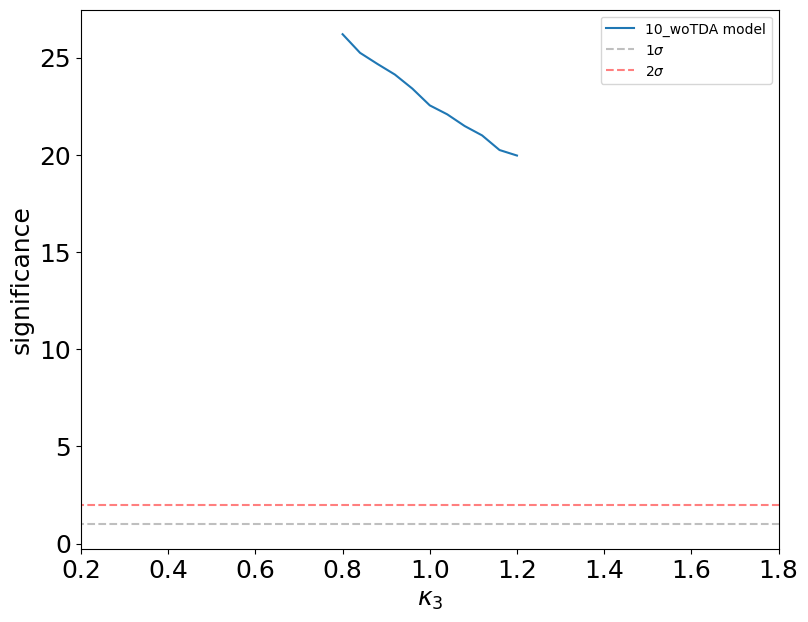

In [8]:
plt.figure(1, figsize=(9,7))
for i in range(len(kappa3_str)):
    plt.plot(kappa3, significance_list[i], label=kappa3_str[i]+" model")
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.xlim(0.2,1.8)
plt.hlines(1, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"1$\sigma$")
plt.hlines(2, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"2$\sigma$")
plt.legend()
plt.show()

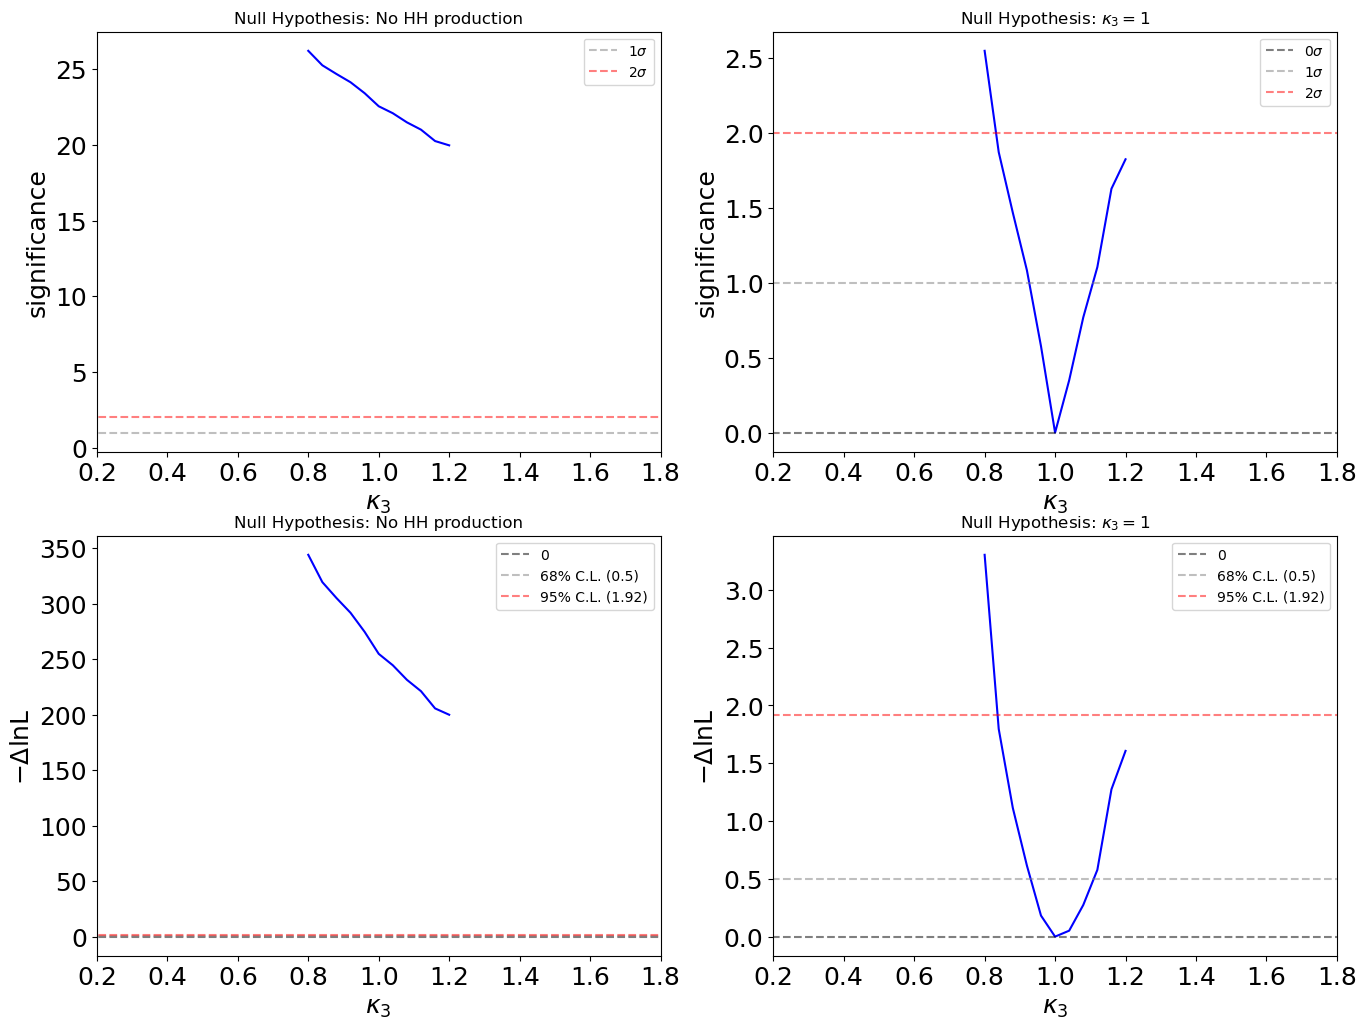

In [9]:
##### calculate different significance with different hypothesis #####

b_plus_s10 = b_10 + s_10[kappa3.index(1.0)]
s_10_modified = [np.sum((s_10[i], b_10)) for i in range(len(s_10))]

significance_null_hypo = []
mDlnL_null_hypo = []
significance_diff_hypo = []
mDlnL_diff_hypo = []

for kappa3_val in kappa3:
    significance_null_hypo.append(cal_significance_smallN(s_10[kappa3.index(kappa3_val)], b_10))
    mDlnL_null_hypo.append(cal_mDlnL(s_10[kappa3.index(kappa3_val)]+b_10, b_10))
    significance_diff_hypo.append(cal_significance_diff_hypo(s_10_modified[kappa3.index(kappa3_val)], b_plus_s10))
    mDlnL_diff_hypo.append(cal_mDlnL(s_10_modified[kappa3.index(kappa3_val)], b_plus_s10))

fig = plt.figure(figsize=(16, 12))

fig.add_subplot(221)
plt.plot(kappa3, significance_null_hypo, color='b')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.xlim(0.2,1.8)
plt.hlines(1, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"1$\sigma$")
plt.hlines(2, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"2$\sigma$")
plt.title("Null Hypothesis: No HH production")
plt.legend()

fig.add_subplot(222)
plt.plot(kappa3, significance_diff_hypo, color='b')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.xlim(0.2,1.8)
plt.hlines(0, -10, 10, color='black', alpha=0.5, linestyle="--", label=r"0$\sigma$")
plt.hlines(1, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"1$\sigma$")
plt.hlines(2, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"2$\sigma$")
plt.title("Null Hypothesis: $\kappa_3=1$")
plt.legend()

fig.add_subplot(223)
plt.plot(kappa3, mDlnL_null_hypo, color='b')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"$-\Delta$lnL", fontsize=18)
plt.xlim(0.2,1.8)
plt.hlines(0, -10, 10, color='black', alpha=0.5, linestyle="--", label=r"0")
plt.hlines(0.5, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"68% C.L. (0.5)")
plt.hlines(1.92, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"95% C.L. (1.92)")
plt.title("Null Hypothesis: No HH production")
plt.legend()

fig.add_subplot(224)
plt.plot(kappa3, mDlnL_diff_hypo, color='b')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"$-\Delta$lnL", fontsize=18)
plt.hlines(0, -10, 10, color='black', alpha=0.5, linestyle="--", label=r"0")
plt.hlines(0.5, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"68% C.L. (0.5)")
plt.hlines(1.92, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"95% C.L. (1.92)")
plt.xlim(0.2,1.8)
plt.title("Null Hypothesis: $\kappa_3=1$")
plt.legend()

plt.show()

In [10]:
print("##### For Null Hyppothesis: No HH Production #####")
print("significance (calculated by p-value directly):\n", significance_null_hypo)
print("-$\Delta$lnL:\n", mDlnL_null_hypo)

print("\n##### For Null Hyppothesis: kappa3 = 1 #####")
print("significance (calculated by p-value directly):\n", significance_diff_hypo)
print("-$\Delta$lnL:\n", mDlnL_diff_hypo)

##### For Null Hyppothesis: No HH Production #####
significance (calculated by p-value directly):
 [26.20167486593317, 25.245060612007983, 24.672051451814106, 24.126173674620166, 23.404750225876604, 22.541963261974104, 22.08176410122687, 21.480080179224736, 20.997851284224488, 20.24560986656514, 19.961856385856972]
-$\Delta$lnL:
 [343.9958756468247, 319.3792898564241, 305.07208339093296, 291.74755834951645, 274.59499077861784, 254.7644393676296, 244.49134269987547, 231.37914029640066, 221.13135692448546, 205.60959597111554, 199.90151095300178]

##### For Null Hyppothesis: kappa3 = 1 #####
significance (calculated by p-value directly):
 [2.5446406740679195, 1.8694427808723812, 1.4659416435715162, 1.0822189996975264, 0.5761296261804998, 0, 0.3488014006173224, 0.7680477045067711, 1.1034028068791653, 1.625334110873947, 1.821824282214918]
-$\Delta$lnL:
 [3.3023817146007843, 1.7961071702980291, 1.1132519572118156, 0.6146663743482748, 0.18187157683092892, 0.0, 0.05150543952035491, 0.273640337

In [11]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:49.7148 (s)
